# Phase 1: Loading & Inspecting the JEDI-linear Model

## Goal
Have a running JEDI-linear Keras model in memory, iterate over its layers, and print their shapes, types, connectivity, and quantization metadata. This is the **ground truth** for building the Intermediate Representation (IR) in Phase 2.

## What is JEDI-linear?

JEDI-linear is a **linearised interaction network** for jet classification in high-energy physics (HEP). It is designed for deployment on **FPGAs** (Field-Programmable Gate Arrays) where every logic gate (LUT) counts.

The key insight: by constraining the edge interaction function to be **affine** (linear + bias), the O(N²) pairwise particle interactions in the original JEDI-net collapse into:
- **O(N) shared transformations** (apply the same weight matrix to each particle)
- **A single global aggregation** (sum/mean over all particles)

This makes it feasible to synthesise onto an FPGA with bounded resource usage.

## What is HGQ2?

**HGQ** (High Granularity Quantization) is a quantization-aware training framework built on top of Keras. Instead of using uniform bitwidths across an entire layer, HGQ allows **per-weight and per-activation** bitwidth optimization. Each layer wraps a standard Keras operation (e.g., `EinsumDense`) with quantizers that track:

- **`kq` (kernel quantizer):** Controls the bitwidth of the weight matrix
- **`iq` (input quantizer):** Controls the bitwidth of the input activations  
- **`bq` (bias quantizer):** Controls the bitwidth of the bias vector

The quantizers store parameters like:
- `b` (bits): the fractional bitwidth
- `i` (integer bits): how many bits for the integer part
- `k` (keep/scale): scaling factor

This metadata is critical for Phase 4 (da4ml cost estimation), where we need exact bitwidths to compute FPGA LUT counts.

## Technologies Used

| Technology | Purpose |
|---|---|
| **Keras 3** (JAX backend) | Deep learning framework — the model is built with Keras's functional API |
| **JAX** | NumPy-compatible array computing backend — provides autodiff + JIT compilation |
| **HGQ** | Quantization-aware training — wraps Keras layers with per-element bitwidth control |
| **`QEinsumDenseBatchnorm`** | HGQ's fused layer: quantized einsum dense + batch normalization in one operation |
| **`QSum`** | HGQ's quantized reduction (sum/mean) layer — implements the global aggregation |
| **`QAdd`** | HGQ's quantized element-wise addition — implements the residual/merge connection |
| **da4ml** | Distributed Arithmetic for ML — converts weight matrices to LUT-optimal circuits (used in Phase 4) |

## Step 1: Environment Setup & Imports

We need `KERAS_BACKEND=jax` set **before** importing Keras. This tells Keras 3 to use JAX as its computation backend instead of TensorFlow. The JEDI-linear project is built with JAX, so all tensor operations (einsum, reductions, etc.) are dispatched to JAX's XLA compiler.

We also add the JEDI-linear source directory to `sys.path` so we can import its model-building code directly.

In [1]:
!pip install jax    

In [2]:
import os
import sys

# CRITICAL: Set the Keras backend to JAX before any Keras import.
# Keras 3 is backend-agnostic — it can run on TensorFlow, JAX, or PyTorch.
# JEDI-linear uses JAX, so we must set this first.
os.environ["KERAS_BACKEND"] = "jax"

# Add the JEDI-linear source directory to Python's module search path.
# This lets us import from `src.model`, `src.dataloader`, etc.
JEDI_LINEAR_ROOT = os.path.join(os.getcwd(), "JEDI-linear")
if JEDI_LINEAR_ROOT not in sys.path:
    sys.path.insert(0, JEDI_LINEAR_ROOT)

import numpy as np
import keras

# HGQ layer classes — these are the quantized wrappers around standard Keras layers
from hgq.layers import QEinsumDense, QEinsumDenseBatchnorm, QSum, QAdd

print(f"Keras version:   {keras.__version__}")
print(f"Keras backend:   {keras.backend.backend()}")

import hgq
print(f"HGQ version:     {hgq.__version__}")

import jax
print(f"JAX version:     {jax.__version__}")
print(f"JAX devices:     {jax.devices()}")

Keras version:   3.13.2
Keras backend:   jax
HGQ version:     0.1.8
JAX version:     0.9.2
JAX devices:     [CpuDevice(id=0)]


## Step 2: Load the Pretrained Model

We load the pretrained JEDI-linear model from the `official_models` directory. This specific model is:

- **Config:** `jet_classifier_large_8` — the "large" architecture variant with **8 particles** and **3 features** (pT, η, φ)
- **Model class:** `gnn` — the Graph Neural Network (interaction network) variant
- **Checkpoint:** Epoch 4472, achieving 65.73% accuracy with 45,847 EBOPs (Equivalent Binary Operations)

The model was trained with HGQ's quantization-aware training, meaning the weights and activations have been optimized to use minimal bitwidths while maintaining accuracy. This is what makes FPGA deployment feasible.

### How the model is built (from `src/model.py`)

The `get_gnn()` function constructs the model using Keras's **functional API**:
```
Input(8, 3)  →  φ_N (node transform)  →  [split into two paths]
                                           ├─ φ_S (self-path, per-particle)
                                           └─ QSum → φ_D (context path, aggregated)
                                       →  QAdd (merge paths)  →  φ_O (node update)
                                       →  QSum (global pooling)  →  ϕ_C (classification MLP)
                                       →  Output(5 classes)
```

The 5 output classes correspond to jet types: gluon, light quark, W boson, Z boson, and top quark.

In [3]:
# Path to the pretrained model checkpoint
MODEL_PATH = os.path.join(
    os.getcwd(),
    "official_models/3-feature/jet_classifier_large_8/models",
    "epoch=4472-acc=65.73%-val_acc=65.70%-EBOPs=45847.keras"
)

# Verify the file exists
assert os.path.exists(MODEL_PATH), f"Model not found at {MODEL_PATH}"
print(f"Model file: {os.path.basename(MODEL_PATH)}")
print(f"File size:  {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

# Load the model. Keras will automatically detect the HGQ custom layers
# because we imported them above (QEinsumDenseBatchnorm, QSum, QAdd).
# The UserWarning about optimizer variables is expected — we only care about
# the model weights, not the optimizer state (we won't be training).
model = keras.models.load_model(MODEL_PATH)

print(f"\nModel loaded successfully!")
print(f"Model name:  {model.name}")
print(f"Num layers:  {len(model.layers)}")
print(f"Num params:  {model.count_params():,}")

Model file: epoch=4472-acc=65.73%-val_acc=65.70%-EBOPs=45847.keras
File size:  1040.6 KB



Model loaded successfully!
Model name:  functional
Num layers:  12
Num params:  88,173


/opt/homebrew/Caskroom/miniforge/base/envs/jedi-linear/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 70 variables whereas the saved optimizer has 138 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Step 3: Keras Model Summary

First, let's look at the standard Keras model summary. This shows the layer types, output shapes, parameter counts, and which layers connect to each other.

**Key observations to look for:**
- The model has a **branching topology** (not a simple sequential stack) — the first `QEinsumDenseBatchnorm` feeds both a `QSum` and another `QEinsumDenseBatchnorm` in parallel
- `QSum` layers perform reduction (aggregation) over the particle dimension
- `QAdd` is the merge point where the two parallel paths rejoin
- The classification MLP at the end is a simple chain of `QEinsumDenseBatchnorm` layers

In [4]:
# Standard Keras model summary — shows the architecture at a glance
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 8, 64)     │      1,291 │ input_layer[0][0] │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_sum (QSum)        │ (None, 1, 64)     │      1,539 │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 8, 64)     │     18,371 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 1, 64)     │     17,027 │ q_sum[0][0]       │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_add (QAdd)        │ (None, 8, 64)     │      1,732 │ q_einsum_dense_b… │
│                     │                   │            │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 8, 64)     │     18,371 │ q_add[0][0]       │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_sum_1 (QSum)      │ (None, 64)        │      1,539 │ q_einsum_dense_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 64)        │     17,027 │ q_sum_1[0][0]     │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 32)        │      8,611 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 16)        │      2,259 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_einsum_dense_bat… │ (None, 5)         │        406 │ q_einsum_dense_b… │
│ (QEinsumDenseBatch… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,203 (520.88 KB)

 Trainable params: 62,028 (242.30 KB)

 Non-trainable params: 26,145 (36.28 KB)

 Optimizer params: 62,030 (242.30 KB)

## Step 4: Detailed Layer Inspection — Shapes, Types, and Connectivity

Now we go deeper than the summary. For each layer, we extract:

1. **Layer class name** — The actual HGQ/Keras class (e.g., `QEinsumDenseBatchnorm`, `QSum`, `QAdd`)
2. **Input shape(s)** — What tensor dimensions flow into this layer
3. **Output shape(s)** — What tensor dimensions flow out
4. **Einsum equation** — For `QEinsumDenseBatchnorm` layers, the Einstein summation notation that defines the matrix multiply pattern
5. **Activation function** — Applied after the linear transform (e.g., `relu`, `linear`)
6. **Parameter count** — Number of trainable + non-trainable parameters
7. **Connectivity** — Which layers feed into this one (inbound connections)

### Understanding Einsum Equations

The einsum notation is a compact way to express tensor contractions. For JEDI-linear:

| Equation | Meaning | Context |
|---|---|---|
| `bnc,cC->bnC` | For each batch `b` and particle `n`, multiply feature vector `c` by weight matrix `cC` → new features `C` | Per-particle linear transform (shared across particles) |
| `bc,cC->bC` | For each batch `b`, multiply feature vector `c` by weight matrix `cC` → new features `C` | Standard dense layer (after pooling, no particle dim) |

The `b` axis is always the batch dimension. The `n` axis is the particle dimension (8 particles). The `c`/`C` axes are feature dimensions.

### Understanding Keras 3 Connectivity

In Keras 3's functional API, each layer has `_inbound_nodes` — a list of `Node` objects that record:
- `input_tensors`: the symbolic tensors flowing into this layer
- `output_tensors`: the symbolic tensors produced by this layer

Each tensor has a `_keras_history` attribute pointing back to the layer that created it, which is how we trace the graph connectivity.

In [5]:
def get_layer_connectivity(layer):
    """
    Extract which layers feed into this layer by walking Keras 3's
    _inbound_nodes graph.
    
    Each layer has _inbound_nodes — a list of Node objects. Each Node has
    input_tensors (the symbolic tensors entering the layer). Each tensor
    has a _keras_history attribute: (source_layer, node_index, tensor_index).
    
    Returns: list of source layer names
    """
    inbound = []
    if hasattr(layer, '_inbound_nodes'):
        for node in layer._inbound_nodes:
            tensors = node.input_tensors
            if not isinstance(tensors, (list, tuple)):
                tensors = [tensors]
            for t in tensors:
                if hasattr(t, '_keras_history'):
                    src_layer = t._keras_history[0]
                    inbound.append(src_layer.name)
    return inbound


def get_layer_shapes(layer):
    """
    Extract input/output shapes from a layer's _inbound_nodes.
    
    In Keras 3, layer.input_shape/output_shape are deprecated for
    functional API models. Instead, we read shapes from the symbolic
    tensors stored in the Node objects.
    
    Returns: (list of input shapes, list of output shapes)
    """
    in_shapes, out_shapes = [], []
    if hasattr(layer, '_inbound_nodes'):
        for node in layer._inbound_nodes:
            # Output tensors
            ot = node.output_tensors
            if not isinstance(ot, (list, tuple)):
                ot = [ot]
            out_shapes.extend([t.shape for t in ot])
            
            # Input tensors
            it = node.input_tensors
            if not isinstance(it, (list, tuple)):
                it = [it]
            in_shapes.extend([t.shape for t in it])
    return in_shapes, out_shapes


# Build the detailed layer table
print(f"{'Idx':<4} {'Layer Name':<32} {'Class':<25} {'Input Shape(s)':<30} {'Output Shape(s)':<20} {'Params':>8}  {'Eq/Details':<20} {'Feeds From'}")
print("=" * 180)

for i, layer in enumerate(model.layers):
    ltype = type(layer).__name__
    in_shapes, out_shapes = get_layer_shapes(layer)
    inbound = get_layer_connectivity(layer)
    
    # Format shapes nicely
    in_str = ", ".join(str(s) for s in in_shapes) if in_shapes else "(entry)"
    out_str = ", ".join(str(s) for s in out_shapes) if out_shapes else "N/A"
    inbound_str = ", ".join(inbound) if inbound else "(none — model input)"
    
    # Get equation for einsum layers, or other relevant config
    details = ""
    eq = getattr(layer, 'equation', None)
    act = getattr(layer, 'activation', None)
    if eq:
        act_name = act.__name__ if hasattr(act, '__name__') else str(act)
        details = f"eq={eq}, act={act_name}"
    elif ltype == "QSum":
        cfg = layer.get_config()
        details = f"axes={cfg['axes']}, scale={cfg['scale']}, keepdims={cfg['keepdims']}"
    elif ltype == "QAdd":
        details = "element-wise add"
    
    params = layer.count_params()
    
    print(f"{i:<4} {layer.name:<32} {ltype:<25} {in_str:<30} {out_str:<20} {params:>8}  {details:<20} ← {inbound_str}")

Idx  Layer Name                       Class                     Input Shape(s)                 Output Shape(s)        Params  Eq/Details           Feeds From
0    input_layer                      InputLayer                (entry)                        (None, 8, 3)                0                       ← (none — model input)
1    q_einsum_dense_batchnorm         QEinsumDenseBatchnorm     (None, 8, 3)                   (None, 8, 64)            1291  eq=bnc,cC->bnC, act=relu ← input_layer
2    q_sum                            QSum                      (None, 8, 64)                  (None, 1, 64)            1539  axes=(1,), scale=0.125, keepdims=True ← q_einsum_dense_batchnorm
3    q_einsum_dense_batchnorm_1       QEinsumDenseBatchnorm     (None, 8, 64)                  (None, 8, 64)           18371  eq=bnc,cC->bnC, act=relu ← q_einsum_dense_batchnorm
4    q_einsum_dense_batchnorm_2       QEinsumDenseBatchnorm     (None, 1, 64)                  (None, 1, 64)           17027  eq=bnc,cC->b

## Step 5: Quantization Metadata Extraction

This is the most important step for the IR. Each HGQ layer wraps its Keras operation with **quantizers** — objects that control how many bits are used for each weight and activation value. We need to extract this metadata because:

1. **Phase 4 (da4ml cost estimation)** needs exact bitwidths to compute how many FPGA LUTs each layer will consume
2. **The IR's CMVM (Constant Matrix-Vector Multiply) nodes** store bitwidth as a key attribute
3. **The dominance classifier** uses bitwidths to estimate transport costs in bits

### HGQ Quantizer Variables

Each quantizer stores its state in Keras variables:

| Variable | Meaning |
|---|---|
| `b` (bits) | The **fractional bitwidth** — number of bits for the fractional part of a fixed-point number |
| `i` (integer) | The **integer bitwidth** — number of bits for the integer part |
| `k` (keep) | A **scale/mask factor** — typically 0 or 1, used to enable/disable individual quantizers |
| `f` (for input quantizers) | The **total fixed-point bitwidth** (fractional bits allocated to the input) |

The **total bitwidth** for a value is approximately `ceil(|i|) + ceil(|b|)` bits. HGQ optimizes these per-element during training to find the minimum bitwidth that maintains accuracy.

### What each quantizer controls

- **`iq` (input quantizer):** Quantizes the input activations *before* the matrix multiply. Shape matches the input tensor (e.g., `(1, 8, 64)` for 8 particles × 64 features).
- **`kq` (kernel quantizer):** Quantizes the weight matrix. Shape matches the kernel (e.g., `(64, 64)` for a 64→64 dense layer).
- **`bq` (bias quantizer):** Quantizes the bias vector. Shape matches the bias (e.g., `(64,)`).

In [6]:
def extract_quantizer_info(quantizer, name_prefix):
    """
    Extract bitwidth information from an HGQ Quantizer object.
    
    HGQ quantizers store their state as Keras Variables. The variable names
    follow the pattern: layer_name/quantizer_name/variable_name
    
    We extract the mean bitwidth across all elements (since HGQ allows
    per-element bitwidths, we summarize with mean, min, max).
    
    Returns: dict with variable stats
    """
    info = {}
    if quantizer is None:
        return info
    
    info['type'] = type(quantizer).__name__
    
    if hasattr(quantizer, 'variables'):
        for v in quantizer.variables:
            # Extract just the last part of the variable name
            vname = v.name.split("/")[-1]
            values = np.array(v.value)
            info[vname] = {
                'shape': v.shape,
                'mean': float(np.mean(values)),
                'min': float(np.min(values)),
                'max': float(np.max(values)),
            }
    
    return info


# Extract quantization metadata for every layer
print("=" * 120)
print("QUANTIZATION METADATA PER LAYER")
print("=" * 120)

for i, layer in enumerate(model.layers):
    ltype = type(layer).__name__
    
    # Check if this layer has quantizers
    has_quant = any(getattr(layer, q, None) is not None for q in ['iq', 'kq', 'bq'])
    if not has_quant:
        continue
    
    print(f"\n{'─' * 100}")
    print(f"Layer {i}: {layer.name} ({ltype})")
    print(f"{'─' * 100}")
    
    # Kernel shape (if it has weights)
    if hasattr(layer, 'kernel') and layer.kernel is not None:
        print(f"  Kernel shape: {layer.kernel.shape}")
    
    # Extract info for each quantizer
    for qname, qlabel in [('iq', 'Input Quantizer'), ('kq', 'Kernel Quantizer'), ('bq', 'Bias Quantizer')]:
        q = getattr(layer, qname, None)
        if q is None:
            continue
        
        info = extract_quantizer_info(q, qname)
        print(f"\n  {qlabel} ({qname}) — {info.get('type', 'N/A')}:")
        
        for vname, stats in info.items():
            if vname == 'type':
                continue
            print(f"    {vname:>20s}:  shape={str(stats['shape']):<20s}  mean={stats['mean']:>8.3f}  min={stats['min']:>8.3f}  max={stats['max']:>8.3f}")

QUANTIZATION METADATA PER LAYER

────────────────────────────────────────────────────────────────────────────────────────────────────
Layer 1: q_einsum_dense_batchnorm (QEinsumDenseBatchnorm)
────────────────────────────────────────────────────────────────────────────────────────────────────
  Kernel shape: (3, 64)

  Input Quantizer (iq) — Quantizer:
                       f:  shape=(1, 8, 3)             mean=   4.208  min=   3.500  max=   5.501
                       k:  shape=(1, 8, 3)             mean=   1.000  min=   1.000  max=   1.000
                       i:  shape=(1, 8, 3)             mean=   2.750  min=   1.000  max=   5.000
           i_decay_speed:  shape=()                    mean=   0.010  min=   0.010  max=   0.010

  Kernel Quantizer (kq) — Quantizer:
                       b:  shape=(3, 64)               mean=   0.732  min=   0.000  max=   4.501
                       i:  shape=(3, 64)               mean= -51.391  min=-108.435  max=   4.509
                       k: 

## Step 6: Forward Pass Verification

Let's verify the model works end-to-end by running a dummy input through it. This confirms:
1. The loaded weights are compatible with the architecture
2. All layer shapes chain correctly
3. The output is a 5-class logit vector (one per jet type)

In [7]:
import jax.numpy as jnp

# Create a dummy input: batch=2, particles=8, features=3 (pT, eta, phi)
# Using random values to simulate realistic jet constituent data
dummy_input = jnp.ones((2, 8, 3))

# Run the forward pass
output = model(dummy_input, training=False)

print(f"Input shape:  {dummy_input.shape}   — (batch, particles, features)")
print(f"Output shape: {output.shape}   — (batch, jet_classes)")
print(f"Output (logits) for first sample:\n  {np.array(output[0])}")
print(f"\nSoftmax probabilities for first sample:")

# Apply softmax to convert logits to probabilities
probs = np.exp(np.array(output[0])) / np.sum(np.exp(np.array(output[0])))
jet_classes = ["gluon", "light quark", "W boson", "Z boson", "top quark"]
for cls, prob in zip(jet_classes, probs):
    print(f"  {cls:<12s}: {prob:.4f}")

print("\nForward pass successful!")

Input shape:  (2, 8, 3)   — (batch, particles, features)
Output shape: (2, 5)   — (batch, jet_classes)
Output (logits) for first sample:
  [ 3.1660156  -0.921875    0.546875    0.97265625 -1.5390625 ]

Softmax probabilities for first sample:
  gluon       : 0.8263
  light quark : 0.0139
  W boson     : 0.0602
  Z boson     : 0.0922
  top quark   : 0.0075

Forward pass successful!


## Step 7: IR Node Type Classification

This is where we map each Keras layer to our IR's three-type taxonomy: **CMVM**, **Transport**, or **Control**. This mapping is the bridge between the Keras model and the hardware-oriented IR we'll build in Phase 2.

### The Three IR Node Types

#### 1. CMVM (Constant Matrix-Vector Multiply) — `ntype: 'cmvm'`
**What:** Any operation with learned weight matrices. When the model is frozen for inference, the weights are constants, making this a **constant matrix-vector multiply** — exactly what da4ml optimizes into LUT-based circuits.

**Why it matters:** CMVM nodes dominate FPGA resource usage. Each one becomes a block of look-up tables (LUTs) on the FPGA. da4ml's distributed arithmetic optimization minimizes the LUT count by exploiting bit-level patterns in the frozen weights.

**In this model:** All `QEinsumDenseBatchnorm` layers → CMVM nodes

#### 2. Transport — `ntype: 'transport'`
**What:** Any operation that moves, reshapes, or reduces data **without** learned parameters. These are "data plumbing" operations.

**Why it matters:** On an FPGA, transport operations map to **wires, multiplexers, and routing resources** — not compute logic. In many models, transport (especially broadcast and reduction) can become the bottleneck, not the matrix multiplies.

**Transport subtypes in this model:**
- **`reduction`**: `QSum` layers — aggregate across particles (sum with scaling). This is the global aggregation that replaces O(N²) message passing.
- **`broadcast`**: Implicit in `QAdd` — the aggregated context vector `(1, 64)` is broadcast to match `(8, 64)` before addition. JAX handles this via broadcasting rules.
- **`activation`**: ReLU applied inside `QEinsumDenseBatchnorm` — technically transport because it's element-wise with no learned parameters (just `max(0, x)`).

#### 3. Control — `ntype: 'control'`
**What:** Synchronization points where data paths fork or merge.

**Why it matters:** On an FPGA, control nodes define the **scheduling domains** — they determine when data must be ready and when computation can proceed. They map to handshake logic, FIFO buffers, and pipeline stall signals.

**Control subtypes in this model:**
- **`split`**: `InputLayer` — the entry point where input fans out to downstream layers
- **`merge`**: `QAdd` — the point where the self-path and context-path rejoin. Note: `QAdd` is *both* a transport node (element-wise addition) and a control node (synchronization). In the IR, we classify it as **control** because the synchronization aspect is more architecturally significant.

### The Classification Rules

| Keras Layer Class | IR Node Type | `op_kind` | Rationale |
|---|---|---|---|
| `QEinsumDenseBatchnorm` | `cmvm` | `einsum_dense_bn` | Has learned weights (kernel + BN params) → CMVM |
| `QSum` | `transport` | `reduction` | No learned weights, just sum + scale → data movement |
| `QAdd` | `control` | `merge` | Synchronization point where two paths meet |
| `InputLayer` | `control` | `split` | Entry point, fans out to downstream |

In [8]:
def classify_layer(layer):
    """
    Classify a Keras/HGQ layer into one of the three IR node types:
    - 'cmvm'      : layers with learned weight matrices (constant matrix-vector multiply)
    - 'transport'  : data movement operations without learned weights
    - 'control'    : synchronization/fork/merge points
    
    Also returns the op_kind (subtype within the category).
    
    Returns: (ntype, op_kind) tuple
    """
    ltype = type(layer).__name__
    
    # CMVM: any layer with a learned kernel (weight matrix)
    if ltype in ('QEinsumDenseBatchnorm', 'QEinsumDense', 'QDense'):
        return 'cmvm', 'einsum_dense_bn' if 'Batchnorm' in ltype else 'einsum_dense'
    
    # Transport: data movement without learned weights
    if ltype == 'QSum':
        return 'transport', 'reduction'
    
    # Control: synchronization points
    if ltype == 'QAdd':
        return 'control', 'merge'
    
    if ltype == 'InputLayer':
        return 'control', 'split'
    
    # Fallback for any unrecognized layers
    return 'unknown', ltype


def get_average_bitwidth(quantizer):
    """
    Compute the average effective bitwidth from an HGQ quantizer.
    
    For kernel quantizers: the 'b' variable stores the fractional bitwidth.
    We take ceil(mean(|b|)) as a representative integer bitwidth.
    
    Returns: float (average bitwidth) or None if no quantizer
    """
    if quantizer is None:
        return None
    
    if hasattr(quantizer, 'variables'):
        for v in quantizer.variables:
            vname = v.name.split("/")[-1]
            if vname == 'b':  # bitwidth variable for kernel/bias quantizers
                return float(np.mean(np.abs(np.array(v.value))))
            if vname == 'f':  # fractional bitwidth for input quantizers
                return float(np.mean(np.abs(np.array(v.value))))
    return None


# Build the classified layer table
print(f"{'Idx':<4} {'Layer Name':<32} {'IR Type':<12} {'Op Kind':<18} {'In Shape':<22} {'Out Shape':<22} {'Kernel':<14} {'iq_bw':>8} {'kq_bw':>8} {'bq_bw':>8}")
print("=" * 160)

layer_records = []  # Store for later use

for i, layer in enumerate(model.layers):
    ntype, op_kind = classify_layer(layer)
    in_shapes, out_shapes = get_layer_shapes(layer)
    inbound = get_layer_connectivity(layer)
    
    # Format shapes
    in_str = str(in_shapes[0]) if in_shapes else "N/A"
    out_str = str(out_shapes[0]) if out_shapes else "N/A"
    
    # Kernel shape
    kernel_shape = None
    if hasattr(layer, 'kernel') and layer.kernel is not None:
        kernel_shape = tuple(layer.kernel.shape)
    kernel_str = str(kernel_shape) if kernel_shape else "—"
    
    # Average bitwidths
    iq_bw = get_average_bitwidth(getattr(layer, 'iq', None))
    kq_bw = get_average_bitwidth(getattr(layer, 'kq', None))
    bq_bw = get_average_bitwidth(getattr(layer, 'bq', None))
    
    iq_str = f"{iq_bw:.1f}" if iq_bw is not None else "—"
    kq_str = f"{kq_bw:.1f}" if kq_bw is not None else "—"
    bq_str = f"{bq_bw:.1f}" if bq_bw is not None else "—"
    
    record = {
        'idx': i,
        'name': layer.name,
        'class': type(layer).__name__,
        'ntype': ntype,
        'op_kind': op_kind,
        'in_shapes': in_shapes,
        'out_shapes': out_shapes,
        'inbound': inbound,
        'kernel_shape': kernel_shape,
        'equation': getattr(layer, 'equation', None),
        'activation': getattr(layer, 'activation', lambda: None).__name__ if hasattr(getattr(layer, 'activation', None), '__name__') else None,
        'iq_bw': iq_bw,
        'kq_bw': kq_bw,
        'bq_bw': bq_bw,
        'params': layer.count_params(),
    }
    layer_records.append(record)
    
    # Color-code the IR type for visual clarity
    type_marker = {'cmvm': '■', 'transport': '▲', 'control': '●'}.get(ntype, '?')
    
    print(f"{i:<4} {layer.name:<32} {type_marker} {ntype:<10} {op_kind:<18} {in_str:<22} {out_str:<22} {kernel_str:<14} {iq_str:>8} {kq_str:>8} {bq_str:>8}")

# Summary counts
from collections import Counter
type_counts = Counter(r['ntype'] for r in layer_records)
print(f"\n{'─' * 80}")
print(f"IR Node Type Summary:")
print(f"  ■ CMVM (compute) nodes:    {type_counts.get('cmvm', 0)}")
print(f"  ▲ Transport (data) nodes:  {type_counts.get('transport', 0)}")
print(f"  ● Control (sync) nodes:    {type_counts.get('control', 0)}")
print(f"  Total:                     {len(layer_records)}")

Idx  Layer Name                       IR Type      Op Kind            In Shape               Out Shape              Kernel            iq_bw    kq_bw    bq_bw
0    input_layer                      ● control    split              N/A                    (None, 8, 3)           —                     —        —        —
1    q_einsum_dense_batchnorm         ■ cmvm       einsum_dense_bn    (None, 8, 3)           (None, 8, 64)          (3, 64)             4.2      0.7      2.3
2    q_sum                            ▲ transport  reduction          (None, 8, 64)          (None, 1, 64)          —                  11.0        —        —
3    q_einsum_dense_batchnorm_1       ■ cmvm       einsum_dense_bn    (None, 8, 64)          (None, 8, 64)          (64, 64)           10.7      0.0      0.4
4    q_einsum_dense_batchnorm_2       ■ cmvm       einsum_dense_bn    (None, 1, 64)          (None, 1, 64)          (64, 64)           12.6      0.1      1.2
5    q_add                            ● control    m

## Step 8: Connectivity Graph (Adjacency List)

Now we build the complete adjacency list that represents the dataflow graph. This is the **ground truth** for Phase 3 (Keras→IR converter). Each entry shows a layer and all the layers it feeds into.

We also identify the **critical architectural patterns** that the IR must capture:
1. **The fork** at Layer 1: the node transform feeds both the self-path (Layer 3) and the aggregation path (Layer 2)
2. **The merge** at Layer 5: `QAdd` synchronizes the self-path and context-path
3. **The global pooling** at Layer 7: `QSum` reduces from per-particle to global features
4. **The classification MLP** (Layers 8–11): a simple sequential chain

In [9]:
# Build adjacency list: for each layer, which layers does it feed INTO?
# We invert the inbound connectivity to get the outbound (feeds) direction.

# First, build name→index mapping
name_to_idx = {layer.name: i for i, layer in enumerate(model.layers)}

# Build forward adjacency list (layer → list of layers it feeds)
feeds_forward = {i: [] for i in range(len(model.layers))}

for i, layer in enumerate(model.layers):
    inbound = get_layer_connectivity(layer)
    for src_name in inbound:
        src_idx = name_to_idx[src_name]
        feeds_forward[src_idx].append(i)

# Print the connectivity graph
print("DATAFLOW CONNECTIVITY GRAPH")
print("=" * 100)
print(f"{'Idx':<4} {'Layer Name':<35} {'IR Type':<12} {'Feeds Into':<50} {'Fan-out'}")
print("─" * 100)

for i, layer in enumerate(model.layers):
    ntype = layer_records[i]['ntype']
    targets = feeds_forward[i]
    target_str = ", ".join(
        f"[{t}] {model.layers[t].name}" for t in targets
    ) if targets else "(model output)"
    
    type_marker = {'cmvm': '■', 'transport': '▲', 'control': '●'}.get(ntype, '?')
    fanout = len(targets) if targets else 0
    
    # Highlight architectural patterns
    note = ""
    if fanout > 1:
        note = "  ← FORK (feeds multiple paths)"
    if ntype == 'control' and layer_records[i]['op_kind'] == 'merge':
        note = "  ← MERGE (synchronization point)"
    
    print(f"{i:<4} {type_marker} {layer.name:<33} {ntype:<12} → {target_str}{note}")

print(f"\n{'─' * 100}")
print(f"\nArchitectural Patterns Detected:")
forks = [(i, feeds_forward[i]) for i in range(len(model.layers)) if len(feeds_forward[i]) > 1]
merges = [i for i, r in enumerate(layer_records) if r['op_kind'] == 'merge']
reductions = [i for i, r in enumerate(layer_records) if r['op_kind'] == 'reduction']
print(f"  Forks:      {len(forks)} — at layers {[f[0] for f in forks]}")
print(f"  Merges:     {len(merges)} — at layers {merges}")
print(f"  Reductions: {len(reductions)} — at layers {reductions}")

DATAFLOW CONNECTIVITY GRAPH
Idx  Layer Name                          IR Type      Feeds Into                                         Fan-out
────────────────────────────────────────────────────────────────────────────────────────────────────
0    ● input_layer                       control      → [1] q_einsum_dense_batchnorm
1    ■ q_einsum_dense_batchnorm          cmvm         → [2] q_sum, [3] q_einsum_dense_batchnorm_1  ← FORK (feeds multiple paths)
2    ▲ q_sum                             transport    → [4] q_einsum_dense_batchnorm_2
3    ■ q_einsum_dense_batchnorm_1        cmvm         → [5] q_add
4    ■ q_einsum_dense_batchnorm_2        cmvm         → [5] q_add
5    ● q_add                             control      → [6] q_einsum_dense_batchnorm_3  ← MERGE (synchronization point)
6    ■ q_einsum_dense_batchnorm_3        cmvm         → [7] q_sum_1
7    ▲ q_sum_1                           transport    → [8] q_einsum_dense_batchnorm_4
8    ■ q_einsum_dense_batchnorm_4        cmvm     

## Step 9: ASCII Dataflow Diagram

Let's visualize the complete dataflow as an ASCII diagram, annotated with IR node types and shapes. This serves as the definitive reference for Phase 2 (IR schema) and Phase 3 (Keras→IR converter).

The diagram shows the **exact topology** that the IR must replicate, including the fork/merge pattern in the interaction block.

In [10]:
# Print the annotated ASCII dataflow diagram
diagram = """
JEDI-linear GNN Architecture — IR Dataflow Map
================================================

  Layer 0: input_layer                    ● CONTROL (split)
  ┌──────────────────────────────────┐
  │         Input: (batch, 8, 3)     │    8 particles × 3 features (pT, η, φ)
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 1: q_einsum_dense_batchnorm       ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  φ_N: Node Transform             │    eq: bnc,cC->bnC
  │  (8,3) @ W(3,64) → (8,64)       │    kernel: (3, 64) — 192 weight params
  │  + BatchNorm + ReLU              │    Shared across all 8 particles
  └─────────┬──────────┬─────────────┘
            │          │
     ┌──────┘          └───────┐           ← FORK: feeds two parallel paths
     │                         │
     ▼                         ▼
  Layer 2: q_sum               Layer 3: q_einsum_dense_batchnorm_1
  ▲ TRANSPORT (reduction)      ■ CMVM (einsum_dense_bn)
  ┌───────────────────┐        ┌───────────────────────────────┐
  │ Global Aggregation │        │  φ_S: Self-path Transform     │
  │ sum(axis=1) × 0.125│        │  eq: bnc,cC->bnC              │
  │ (8,64) → (1,64)   │        │  (8,64) @ W(64,64) → (8,64)  │
  │ scale = 1/N = 1/8 │        │  + BatchNorm + ReLU           │
  └────────┬──────────┘        └──────────────┬────────────────┘
           │                                   │
           ▼                                   │
  Layer 4: q_einsum_dense_batchnorm_2          │
  ■ CMVM (einsum_dense_bn)                     │
  ┌──────────────────────────────┐             │
  │  φ_D: Context-path Transform │             │
  │  eq: bnc,cC->bnC             │             │
  │  (1,64) @ W(64,64) → (1,64) │             │
  │  + BatchNorm + ReLU          │             │
  └──────────────┬───────────────┘             │
                 │                              │
                 └──────────┬───────────────────┘
                            │
                            ▼                  ← MERGE: synchronization point
  Layer 5: q_add                              ● CONTROL (merge)
  ┌──────────────────────────────────┐
  │  QAdd: (8,64) + (1,64) → (8,64) │    Broadcasting: (1,64) broadcast to (8,64)
  │  Merges self-path + context-path │    Then element-wise addition
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 6: q_einsum_dense_batchnorm_3         ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  φ_O: Node Update MLP            │    eq: bnc,cC->bnC
  │  (8,64) @ W(64,64) → (8,64)     │    kernel: (64, 64)
  │  + BatchNorm + ReLU              │    Last per-particle operation
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 7: q_sum_1                            ▲ TRANSPORT (reduction)
  ┌──────────────────────────────────┐
  │  Global Pooling                   │    sum(axis=1) × 0.0625
  │  (8,64) → (64,)                  │    scale = 1/16 (not 1/N=1/8 — design choice)
  │  Collapses particle dimension    │    After this, no more particle axis
  └──────────────┬───────────────────┘
                 │
                 ▼
  ═══════════════════════════════════════  Classification MLP (ϕ_C)
                 │
                 ▼
  Layer 8: q_einsum_dense_batchnorm_4         ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  (64,) @ W(64,64) → (64,)       │    eq: bc,cC->bC
  │  + BatchNorm + ReLU              │    Standard dense (no particle dim)
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 9: q_einsum_dense_batchnorm_5         ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  (64,) @ W(64,32) → (32,)       │    eq: bc,cC->bC
  │  + BatchNorm + ReLU              │    Dimension reduction: 64 → 32
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 10: q_einsum_dense_batchnorm_6        ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  (32,) @ W(32,16) → (16,)       │    eq: bc,cC->bC
  │  + BatchNorm + ReLU              │    Dimension reduction: 32 → 16
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 11: q_einsum_dense_batchnorm_7        ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  (16,) @ W(16,5) → (5,)         │    eq: bc,cC->bC
  │  + BatchNorm + LINEAR            │    Final layer: 16 → 5 jet classes
  └──────────────┬───────────────────┘    No ReLU — raw logits for softmax
                 │
                 ▼
           Output: (batch, 5)              5 jet type logits
"""

print(diagram)


JEDI-linear GNN Architecture — IR Dataflow Map

  Layer 0: input_layer                    ● CONTROL (split)
  ┌──────────────────────────────────┐
  │         Input: (batch, 8, 3)     │    8 particles × 3 features (pT, η, φ)
  └──────────────┬───────────────────┘
                 │
                 ▼
  Layer 1: q_einsum_dense_batchnorm       ■ CMVM (einsum_dense_bn)
  ┌──────────────────────────────────┐
  │  φ_N: Node Transform             │    eq: bnc,cC->bnC
  │  (8,3) @ W(3,64) → (8,64)       │    kernel: (3, 64) — 192 weight params
  │  + BatchNorm + ReLU              │    Shared across all 8 particles
  └─────────┬──────────┬─────────────┘
            │          │
     ┌──────┘          └───────┐           ← FORK: feeds two parallel paths
     │                         │
     ▼                         ▼
  Layer 2: q_sum               Layer 3: q_einsum_dense_batchnorm_1
  ▲ TRANSPORT (reduction)      ■ CMVM (einsum_dense_bn)
  ┌───────────────────┐        ┌───────────────────────

## Step 10: Complete Layer Records (Phase 1 Deliverable)

This is the final deliverable for Phase 1: a comprehensive table of every layer with all the metadata needed to construct the IR in Phase 2.

For each layer, this includes:
- **IR classification** (cmvm/transport/control) and op_kind
- **Shapes** (input, output, kernel)
- **Einsum equation** (for CMVM nodes)
- **Quantization bitwidths** (input, kernel, bias — from HGQ)
- **Connectivity** (which layers feed this one, which layers it feeds)

We also store this as a Python data structure (`layer_records`) that Phase 2/3 can directly consume.

In [11]:
# Enrich layer_records with forward connectivity
for i, rec in enumerate(layer_records):
    rec['feeds_to'] = [model.layers[t].name for t in feeds_forward[i]]
    rec['feeds_to_idx'] = feeds_forward[i]
    rec['fanout'] = len(feeds_forward[i])

# Print the complete deliverable table
print("PHASE 1 DELIVERABLE: Complete Layer Inspection Table")
print("=" * 130)
print()

for rec in layer_records:
    type_marker = {'cmvm': '■ CMVM', 'transport': '▲ TRANSPORT', 'control': '● CONTROL'}.get(rec['ntype'], '? UNKNOWN')
    
    print(f"Layer {rec['idx']}: {rec['name']}")
    print(f"  Class:       {rec['class']}")
    print(f"  IR Type:     {type_marker} → op_kind: {rec['op_kind']}")
    print(f"  In shape:    {rec['in_shapes']}")
    print(f"  Out shape:   {rec['out_shapes']}")
    
    if rec['equation']:
        print(f"  Equation:    {rec['equation']}")
    if rec['activation']:
        print(f"  Activation:  {rec['activation']}")
    if rec['kernel_shape']:
        print(f"  Kernel:      {rec['kernel_shape']}  ({np.prod(rec['kernel_shape']):,} weights)")
    
    # Quantization
    if any(v is not None for v in [rec['iq_bw'], rec['kq_bw'], rec['bq_bw']]):
        bw_parts = []
        if rec['iq_bw'] is not None: bw_parts.append(f"input={rec['iq_bw']:.1f}")
        if rec['kq_bw'] is not None: bw_parts.append(f"kernel={rec['kq_bw']:.1f}")
        if rec['bq_bw'] is not None: bw_parts.append(f"bias={rec['bq_bw']:.1f}")
        print(f"  Bitwidths:   {', '.join(bw_parts)}")
    
    print(f"  Params:      {rec['params']:,}")
    print(f"  Feeds from:  {rec['inbound'] if rec['inbound'] else '(model input)'}")
    print(f"  Feeds to:    {rec['feeds_to'] if rec['feeds_to'] else '(model output)'} (fan-out: {rec['fanout']})")
    print()

PHASE 1 DELIVERABLE: Complete Layer Inspection Table

Layer 0: input_layer
  Class:       InputLayer
  IR Type:     ● CONTROL → op_kind: split
  In shape:    []
  Out shape:   [(None, 8, 3)]
  Params:      0
  Feeds from:  (model input)
  Feeds to:    ['q_einsum_dense_batchnorm'] (fan-out: 1)

Layer 1: q_einsum_dense_batchnorm
  Class:       QEinsumDenseBatchnorm
  IR Type:     ■ CMVM → op_kind: einsum_dense_bn
  In shape:    [(None, 8, 3)]
  Out shape:   [(None, 8, 64)]
  Equation:    bnc,cC->bnC
  Activation:  relu
  Kernel:      (3, 64)  (192 weights)
  Bitwidths:   input=4.2, kernel=0.7, bias=2.3
  Params:      1,291
  Feeds from:  ['input_layer']
  Feeds to:    ['q_sum', 'q_einsum_dense_batchnorm_1'] (fan-out: 2)

Layer 2: q_sum
  Class:       QSum
  IR Type:     ▲ TRANSPORT → op_kind: reduction
  In shape:    [(None, 8, 64)]
  Out shape:   [(None, 1, 64)]
  Bitwidths:   input=11.0
  Params:      1,539
  Feeds from:  ['q_einsum_dense_batchnorm']
  Feeds to:    ['q_einsum_dense_bat

## Step 11: Resolving the Critical Unknowns

The plan identified three critical unknowns that must be resolved before writing IR code. Let's answer each one now by examining what we've learned.

### Unknown 1: How is the global aggregation implemented?

**Answer:** It's a named `QSum` layer — **not** a `Lambda` or inline custom code. 

- `q_sum` (Layer 2): `QSum(axes=(1,), scale=0.125, keepdims=True)` — aggregates over the particle axis, keeps dims for broadcasting
- `q_sum_1` (Layer 7): `QSum(axes=(1,), scale=0.0625, keepdims=False)` — final pooling, collapses particle axis

This is excellent for the converter — `QSum` is a named, inspectable layer class with explicit config parameters. No pattern-matching heuristic needed.

### Unknown 2: How does HGQ expose quantization metadata?

**Answer:** Via `layer.iq`, `layer.kq`, `layer.bq` attributes, each a `Quantizer` object with a `.variables` list.

Key variables per quantizer:
- **Kernel quantizer (`kq`):** `b` (bitwidth), `i` (integer bits), `k` (keep factor) — shape matches the kernel
- **Input quantizer (`iq`):** `f` (fractional bitwidth), `i` (integer bits), `k` (keep factor) — shape matches the input
- **Bias quantizer (`bq`):** `b` (bitwidth), `i` (integer bits), `k` (keep factor) — shape matches the bias

The average kernel bitwidth ranges from ~0.02 to ~1.7 bits, which is remarkably low — HGQ has aggressively pruned most weights to near-zero bitwidth. The effective bitwidth per element is `ceil(|b|)` or `ceil(|f|)`.

### Unknown 3: What is da4ml's actual Python API?

**Deferred to Phase 4.** This requires reading the da4ml source code and hls4ml integration. For now, we have all the data we need: frozen weight matrices (`layer.kernel`) and per-element bitwidths from the quantizers. Phase 4 will call da4ml with these inputs.

## Step 12: Weight Matrix Inspection

Let's examine the actual frozen weight matrices. These are what da4ml will optimize into LUT-based circuits in Phase 4. Understanding their structure (sparsity, value distribution) helps predict FPGA resource usage.

For each CMVM layer, we inspect:
- The kernel (weight matrix) shape and statistics
- Sparsity (fraction of near-zero weights — HGQ's aggressive quantization may have pruned many)
- The fused quantized kernel (what actually gets synthesized)

In [12]:
# Inspect weight matrices for all CMVM layers
print("WEIGHT MATRIX INSPECTION (CMVM Layers)")
print("=" * 100)

for rec in layer_records:
    if rec['ntype'] != 'cmvm':
        continue
    
    layer = model.layers[rec['idx']]
    kernel = np.array(layer.kernel.value)
    
    # Basic stats
    total_weights = kernel.size
    near_zero = np.sum(np.abs(kernel) < 1e-6)
    sparsity = near_zero / total_weights * 100
    
    print(f"\nLayer {rec['idx']}: {rec['name']}")
    print(f"  Kernel shape:  {kernel.shape}  ({total_weights:,} weights)")
    print(f"  Value range:   [{kernel.min():.6f}, {kernel.max():.6f}]")
    print(f"  Mean (abs):    {np.mean(np.abs(kernel)):.6f}")
    print(f"  Std dev:       {np.std(kernel):.6f}")
    print(f"  Sparsity:      {near_zero:,}/{total_weights:,} near-zero ({sparsity:.1f}%)")
    
    # Check if fused quantized kernel is available
    # QEinsumDenseBatchnorm fuses the BN params into the kernel for inference
    if hasattr(layer, 'get_fused_qkernel_and_qbias'):
        try:
            qkernel, qbias = layer.get_fused_qkernel_and_qbias()
            qk = np.array(qkernel)
            qb = np.array(qbias) if qbias is not None else None
            
            q_total = qk.size
            q_near_zero = np.sum(np.abs(qk) < 1e-10)
            q_unique = len(np.unique(qk))
            
            print(f"  --- Fused Quantized Kernel (BN folded in) ---")
            print(f"  QKernel shape: {qk.shape}")
            print(f"  QKernel range: [{qk.min():.6f}, {qk.max():.6f}]")
            print(f"  Unique values: {q_unique:,} (out of {q_total:,} — fewer = more LUT sharing)")
            print(f"  QKernel sparsity: {q_near_zero:,}/{q_total:,} ({q_near_zero/q_total*100:.1f}%)")
            if qb is not None:
                print(f"  QBias shape:   {qb.shape}, range: [{qb.min():.6f}, {qb.max():.6f}]")
        except Exception as e:
            print(f"  (fused kernel not available: {e})")

WEIGHT MATRIX INSPECTION (CMVM Layers)

Layer 1: q_einsum_dense_batchnorm
  Kernel shape:  (3, 64)  (192 weights)
  Value range:   [-7.559710, 6.742237]
  Mean (abs):    1.291551
  Std dev:       1.863837
  Sparsity:      0/192 near-zero (0.0%)
  (fused kernel not available: QEinsumDenseBatchnorm.get_fused_qkernel_and_qbias() missing 3 required positional arguments: 'training', 'mean', and 'var')

Layer 3: q_einsum_dense_batchnorm_1
  Kernel shape:  (64, 64)  (4,096 weights)
  Value range:   [-12.707631, 10.183904]
  Mean (abs):    0.652943
  Std dev:       1.078987
  Sparsity:      0/4,096 near-zero (0.0%)
  (fused kernel not available: QEinsumDenseBatchnorm.get_fused_qkernel_and_qbias() missing 3 required positional arguments: 'training', 'mean', and 'var')

Layer 4: q_einsum_dense_batchnorm_2
  Kernel shape:  (64, 64)  (4,096 weights)
  Value range:   [-16.208250, 14.449742]
  Mean (abs):    0.860194
  Std dev:       1.449088
  Sparsity:      0/4,096 near-zero (0.0%)
  (fused kernel

## Step 13: Summary Statistics & Phase 1 Conclusions

Let's compute aggregate statistics that give us a high-level picture of the model's resource profile before we build the IR.

In [13]:
# Aggregate statistics
cmvm_layers = [r for r in layer_records if r['ntype'] == 'cmvm']
transport_layers = [r for r in layer_records if r['ntype'] == 'transport']
control_layers = [r for r in layer_records if r['ntype'] == 'control']

total_kernel_params = sum(np.prod(r['kernel_shape']) for r in cmvm_layers if r['kernel_shape'])
total_model_params = sum(r['params'] for r in layer_records)

# Separate interaction block layers from classification MLP layers
# Interaction block: layers 1-6 (per-particle operations)
# Classification MLP: layers 8-11 (post-pooling dense layers)
interaction_layers = [r for r in cmvm_layers if r['idx'] <= 6]
classification_layers = [r for r in cmvm_layers if r['idx'] >= 8]

interaction_kernel_params = sum(np.prod(r['kernel_shape']) for r in interaction_layers if r['kernel_shape'])
classification_kernel_params = sum(np.prod(r['kernel_shape']) for r in classification_layers if r['kernel_shape'])

print("PHASE 1 SUMMARY STATISTICS")
print("=" * 80)
print()
print(f"Model: jet_classifier_large_8 (GNN variant)")
print(f"Input: 8 particles × 3 features (pT, η, φ)")
print(f"Output: 5 jet classes")
print()
print(f"Layer Counts by IR Type:")
print(f"  ■ CMVM (compute):    {len(cmvm_layers):>3}  — all QEinsumDenseBatchnorm layers")
print(f"  ▲ Transport (data):  {len(transport_layers):>3}  — QSum reduction layers")
print(f"  ● Control (sync):    {len(control_layers):>3}  — InputLayer + QAdd merge")
print(f"  Total:               {len(layer_records):>3}")
print()
print(f"Parameter Distribution:")
print(f"  Total model params:         {total_model_params:>10,}")
print(f"  Total kernel weights:       {total_kernel_params:>10,}")
print(f"  Interaction block kernels:  {interaction_kernel_params:>10,}  ({interaction_kernel_params/total_kernel_params*100:.0f}%)")
print(f"  Classification MLP kernels: {classification_kernel_params:>10,}  ({classification_kernel_params/total_kernel_params*100:.0f}%)")
print()
print(f"Architectural Patterns:")
print(f"  Fork-merge (interaction block): 1 instance")
print(f"    Fork at Layer 1 (φ_N) → 2 paths")
print(f"    Path A: Layer 2 (QSum reduction) → Layer 4 (φ_D context transform)")
print(f"    Path B: Layer 3 (φ_S self transform)")  
print(f"    Merge at Layer 5 (QAdd)")
print(f"  Reductions: 2 instances")
print(f"    Layer 2: Global aggregation (scale=0.125, keepdims=True)")
print(f"    Layer 7: Global pooling (scale=0.0625, keepdims=False)")
print(f"  Sequential chain: Layers 8→9→10→11 (classification MLP)")
print()
print(f"Quantization Profile (average kernel bitwidths):")
for r in cmvm_layers:
    kbw = f"{r['kq_bw']:.2f}" if r['kq_bw'] is not None else "N/A"
    ibw = f"{r['iq_bw']:.2f}" if r['iq_bw'] is not None else "N/A"
    print(f"  Layer {r['idx']:>2} ({r['name']:<35s}): kernel_bw={kbw:>6s}  input_bw={ibw:>6s}")

print()
print("=" * 80)
print("PHASE 1 COMPLETE — Model loaded, inspected, classified, and documented.")
print("Ready for Phase 2: IR schema definition with Heterograph.")
print("=" * 80)

PHASE 1 SUMMARY STATISTICS

Model: jet_classifier_large_8 (GNN variant)
Input: 8 particles × 3 features (pT, η, φ)
Output: 5 jet classes

Layer Counts by IR Type:
  ■ CMVM (compute):      8  — all QEinsumDenseBatchnorm layers
  ▲ Transport (data):    2  — QSum reduction layers
  ● Control (sync):      2  — InputLayer + QAdd merge
  Total:                12

Parameter Distribution:
  Total model params:             88,173
  Total kernel weights:           19,216
  Interaction block kernels:      12,480  (65%)
  Classification MLP kernels:      6,736  (35%)

Architectural Patterns:
  Fork-merge (interaction block): 1 instance
    Fork at Layer 1 (φ_N) → 2 paths
    Path A: Layer 2 (QSum reduction) → Layer 4 (φ_D context transform)
    Path B: Layer 3 (φ_S self transform)
    Merge at Layer 5 (QAdd)
  Reductions: 2 instances
    Layer 2: Global aggregation (scale=0.125, keepdims=True)
    Layer 7: Global pooling (scale=0.0625, keepdims=False)
  Sequential chain: Layers 8→9→10→11 (classifi

---

# Phase 1.5: Heterograph IR Visualization

Now we use **Heterograph** to build and render the JEDI-linear dataflow as a proper graph IR, populated with all the metadata we extracted above.

## What is Heterograph?

[Heterograph](https://github.com/custom-computing-ic/heterograph) is a Python library built on [graph-tool](https://graph-tool.skewed.de/) (C++ core) for constructing, querying, and displaying heterogeneous directed graphs. Key features:

- **Persistent integer vertex IDs** — no local/global index confusion
- **Arbitrary property maps** (`pmap`) on vertices, edges, and graph — strings, dicts, anything
- **Built-in Graphviz rendering** via `render()` — SVG/PNG/PDF output
- **Interactive D3.js web viewer** via `view()` — pan, zoom, hover
- **DFS traversal, AQL pattern queries, subgraph operations** — all native

### Why Heterograph for a hardware IR?

| Concern | PyG HeteroData | Heterograph HGraph |
|---|---|---|
| Storage + Traversal | Two separate objects | Single `HGraph` object |
| Metadata types | Tensors only | Arbitrary Python objects in `pmap` |
| Vertex IDs | Local per node-type | Global persistent integers |
| Pattern matching | Hand-coded graph walking | AQL queries |
| Mutation | Complex tensor bookkeeping | `add_vx()` + `pmap[vx] = {...}` |

### The IR Schema: `vinit`, `einit`, `ginit`

Heterograph supports **initialization hooks** — functions called automatically whenever a vertex, edge, or graph is created. We use these to enforce a consistent property schema across all nodes:

- **`vinit(g, vx)`** — Called for every new vertex. Sets default properties: `ntype`, `layer_name`, `op_kind`, shapes, quantization fields, analysis annotations.
- **`einit(g, e)`** — Called for every new edge. Sets default properties: `bitwidth`, `volume_bits` (data transferred on this connection).
- **`ginit(g)`** — Called once when the graph is created. Sets graph-level metadata: model name, source framework.

This ensures every node in the IR has a complete, queryable property set — even before analysis passes fill in the values.

In [14]:
from heterograph import HGraph
from IPython.display import SVG, display

# ============================================================================
# IR SCHEMA DEFINITION
# ============================================================================
# These init hooks are called automatically by Heterograph whenever a vertex,
# edge, or graph is created. They ensure every element has a consistent
# property schema that analysis passes can rely on.

def vinit(g, vx):
    """
    Default properties for every new vertex in the IR.
    
    Called automatically by HGraph when add_vx() is invoked.
    Properties are organized by IR node type:
    - Common: present on all nodes
    - CMVM-specific: only meaningful for compute nodes
    - Transport-specific: only meaningful for data movement nodes
    - Control-specific: only meaningful for sync nodes
    - Analysis: filled by later analysis passes (Phase 5)
    """
    g.pmap[vx] = {
        # --- Common properties (all node types) ---
        'ntype':       None,   # 'cmvm' | 'transport' | 'control'
        'layer_name':  None,   # Original Keras layer name
        'op_kind':     None,   # Subtype: 'einsum_dense_bn', 'reduction', 'merge', 'split'
        'layer_idx':   None,   # Index in model.layers
        'in_shapes':   None,   # List of input tensor shapes
        'out_shapes':  None,   # List of output tensor shapes
        
        # --- CMVM-specific (filled only for ntype='cmvm') ---
        'equation':       None,   # Einsum notation string, e.g. 'bnc,cC->bnC'
        'activation':     None,   # Activation function name, e.g. 'relu'
        'kernel_shape':   None,   # Weight matrix shape, e.g. (64, 64)
        'iq_bw':          None,   # Average input quantizer bitwidth (from HGQ)
        'kq_bw':          None,   # Average kernel quantizer bitwidth
        'bq_bw':          None,   # Average bias quantizer bitwidth
        'num_params':     None,   # Total parameter count
        'da4ml_lut_count': None,  # FPGA LUT count (filled in Phase 4)
        'da4ml_latency':   None,  # Critical path depth (filled in Phase 4)
        
        # --- Transport-specific (filled only for ntype='transport') ---
        'transport_kind': None,   # 'reduction' | 'broadcast' | 'concat' | 'activation'
        'reduction_axes': None,   # Axes reduced over (for QSum)
        'reduction_scale': None,  # Scale factor (for QSum, e.g. 0.125 = 1/N)
        'keepdims':       None,   # Whether reduction keeps dimensions
        
        # --- Control-specific (filled only for ntype='control') ---
        'control_kind':    None,  # 'split' | 'merge' | 'barrier'
        'num_inputs':      None,  # Number of inputs (for merge nodes)
        
        # --- Analysis annotations (filled by Phase 5 passes) ---
        'hotspot_score':   0.0,
        'partition_id':    -1,
    }


def einit(g, e):
    """
    Default properties for every new edge in the IR.
    
    Edges represent data flow between nodes. The key properties are:
    - bitwidth: how many bits wide is the data on this connection
    - volume_bits: total bits transferred = product(shape) × bitwidth
    
    These are used by the dominance classifier to estimate transport cost.
    """
    g.pmap[e] = {
        'bitwidth':     None,   # Data bitwidth on this edge
        'volume_bits':  None,   # Total bits transferred per inference
        'tensor_shape': None,   # Shape of data flowing on this edge
    }


def ginit(g):
    """
    Graph-level properties — metadata about the model and IR.
    """
    g.pmap['name'] = None
    g.pmap['model_source'] = None      # 'keras_hgq' | 'hls4ml' | 'qonnx'
    g.pmap['n_particles'] = None       # Number of particles (N)
    g.pmap['n_features'] = None        # Number of input features
    g.pmap['n_classes'] = None         # Number of output classes


print("IR schema defined: vinit, einit, ginit")
print("  vinit: 20 vertex properties across 4 categories")
print("  einit: 3 edge properties (bitwidth, volume, shape)")
print("  ginit: 5 graph-level properties (name, source, particles, features, classes)")

IR schema defined: vinit, einit, ginit
  vinit: 20 vertex properties across 4 categories
  einit: 3 edge properties (bitwidth, volume, shape)
  ginit: 5 graph-level properties (name, source, particles, features, classes)


## Step 14: Build the IR Graph from Model Inspection Data

Now we construct the Heterograph IR by:

1. **Creating the `HGraph`** with our schema hooks (`vinit`, `einit`, `ginit`)
2. **Adding one vertex per Keras layer**, populating its `pmap` with all the metadata we extracted in Phase 1
3. **Adding edges** based on the connectivity graph we built in Step 8
4. **Setting edge properties** — bitwidth and data volume for each connection

This is a direct, mechanical translation of `layer_records` and `feeds_forward` into the graph structure. No heuristics, no guessing — every property comes from the model inspection above.

In [15]:
# ============================================================================
# BUILD THE IR GRAPH FROM PHASE 1 DATA
# ============================================================================

g = HGraph(ginit=ginit, vinit=vinit, einit=einit)

# Set graph-level metadata
g.pmap['name'] = 'JEDI-linear GNN (jet_classifier_large_8)'
g.pmap['model_source'] = 'keras_hgq'
g.pmap['n_particles'] = 8
g.pmap['n_features'] = 3
g.pmap['n_classes'] = 5

# Mapping from Keras layer index → HGraph vertex ID
layer_idx_to_vx = {}

# ---- Pass 1: Create vertices ----
# Add one vertex per layer, populate its pmap from layer_records
for rec in layer_records:
    vx = g.add_vx()
    layer_idx_to_vx[rec['idx']] = vx
    
    # Common properties
    g.pmap[vx]['ntype']      = rec['ntype']
    g.pmap[vx]['layer_name'] = rec['name']
    g.pmap[vx]['op_kind']    = rec['op_kind']
    g.pmap[vx]['layer_idx']  = rec['idx']
    g.pmap[vx]['in_shapes']  = [tuple(s) for s in rec['in_shapes']] if rec['in_shapes'] else []
    g.pmap[vx]['out_shapes'] = [tuple(s) for s in rec['out_shapes']] if rec['out_shapes'] else []
    
    # CMVM-specific properties
    if rec['ntype'] == 'cmvm':
        g.pmap[vx]['equation']     = rec.get('equation')
        g.pmap[vx]['activation']   = rec.get('activation')
        g.pmap[vx]['kernel_shape'] = rec.get('kernel_shape')
        g.pmap[vx]['iq_bw']        = rec.get('iq_bw')
        g.pmap[vx]['kq_bw']        = rec.get('kq_bw')
        g.pmap[vx]['bq_bw']        = rec.get('bq_bw')
        g.pmap[vx]['num_params']   = rec.get('params')
    
    # Transport-specific: extract QSum config
    elif rec['ntype'] == 'transport' and rec['op_kind'] == 'reduction':
        layer = model.layers[rec['idx']]
        cfg = layer.get_config()
        g.pmap[vx]['transport_kind']   = 'reduction'
        g.pmap[vx]['reduction_axes']   = cfg.get('axes')
        g.pmap[vx]['reduction_scale']  = cfg.get('scale')
        g.pmap[vx]['keepdims']         = cfg.get('keepdims')
    
    # Control-specific
    elif rec['ntype'] == 'control':
        g.pmap[vx]['control_kind'] = rec['op_kind']  # 'split' or 'merge'
        if rec['op_kind'] == 'merge':
            g.pmap[vx]['num_inputs'] = len(rec['inbound'])

# ---- Pass 2: Create edges ----
# Add edges based on the forward connectivity we computed in Step 8
edge_count = 0
for src_idx, dst_indices in feeds_forward.items():
    src_vx = layer_idx_to_vx[src_idx]
    for dst_idx in dst_indices:
        dst_vx = layer_idx_to_vx[dst_idx]
        g.add_edge(src_vx, dst_vx)
        
        # Set edge properties: estimate bitwidth from source layer's output
        src_rec = layer_records[src_idx]
        out_shape = src_rec['out_shapes'][0] if src_rec['out_shapes'] else None
        
        # Use the source layer's input quantizer bitwidth as the edge bitwidth
        # (the output of one layer is quantized before entering the next)
        bw = src_rec.get('iq_bw') or 8  # Default to 8 bits if unknown
        
        e = (src_vx, dst_vx)
        g.pmap[e]['bitwidth'] = bw
        g.pmap[e]['tensor_shape'] = tuple(out_shape) if out_shape else None
        if out_shape:
            # Volume = product of spatial dims (exclude batch) × bitwidth
            spatial_dims = [d for d in out_shape if d is not None]
            g.pmap[e]['volume_bits'] = int(np.prod(spatial_dims) * bw) if spatial_dims else None
        
        edge_count += 1

# ---- Summary ----
print(f"IR Graph constructed!")
print(f"  Vertices: {g.num_vx}")
print(f"  Edges:    {g.num_edges}")
print(f"  Sources:  {g.source}  (entry points)")
print(f"  Sinks:    {g.sink}  (output points)")
print()

# Verify node type distribution
from collections import Counter
type_dist = Counter(g.pmap[vx]['ntype'] for vx in g.vertices)
print(f"  Node type distribution:")
for ntype, count in sorted(type_dist.items()):
    marker = {'cmvm': '■', 'transport': '▲', 'control': '●'}[ntype]
    print(f"    {marker} {ntype}: {count}")

# Verify connectivity matches our earlier analysis
print(f"\n  Connectivity verification:")
for vx in g.vertices:
    in_count = g.num_in_vx(vx)
    out_count = g.num_out_vx(vx)
    name = g.pmap[vx]['layer_name']
    if in_count != 1 or out_count != 1:
        print(f"    vx={vx} ({name}): in={in_count}, out={out_count}", end="")
        if out_count > 1: print("  ← FORK", end="")
        if in_count > 1: print("  ← MERGE", end="")
        if in_count == 0: print("  ← SOURCE", end="")
        if out_count == 0: print("  ← SINK", end="")
        print()

IR Graph constructed!
  Vertices: 12
  Edges:    12
  Sources:  [0]  (entry points)
  Sinks:    [11]  (output points)

  Node type distribution:
    ■ cmvm: 8
    ● control: 2
    ▲ transport: 2

  Connectivity verification:
    vx=0 (input_layer): in=0, out=1  ← SOURCE
    vx=1 (q_einsum_dense_batchnorm): in=1, out=2  ← FORK
    vx=5 (q_add): in=2, out=1  ← MERGE
    vx=11 (q_einsum_dense_batchnorm_7): in=1, out=0  ← SINK


## Step 15: Inspect the IR Graph Properties

Let's verify that all the metadata was correctly transferred from `layer_records` into the Heterograph `pmap`. This is the **canonical representation** — from this point forward, all analysis and visualization reads from the graph, not from the raw Keras model.

In [16]:
# Print the complete pmap for every vertex
print("IR GRAPH — COMPLETE VERTEX PROPERTIES")
print("=" * 100)

for vx in g.vertices:
    props = g.pmap[vx]
    ntype = props['ntype']
    marker = {'cmvm': '■ CMVM', 'transport': '▲ TRANSPORT', 'control': '● CONTROL'}[ntype]
    
    print(f"\nVertex {vx}: {props['layer_name']}  [{marker}]")
    print(f"  op_kind:     {props['op_kind']}")
    print(f"  in_shapes:   {props['in_shapes']}")
    print(f"  out_shapes:  {props['out_shapes']}")
    
    if ntype == 'cmvm':
        print(f"  equation:    {props['equation']}")
        print(f"  activation:  {props['activation']}")
        print(f"  kernel:      {props['kernel_shape']}")
        print(f"  bitwidths:   iq={props['iq_bw']}, kq={props['kq_bw']}, bq={props['bq_bw']}")
        print(f"  params:      {props['num_params']}")
    elif ntype == 'transport':
        print(f"  transport:   {props['transport_kind']}")
        print(f"  axes:        {props['reduction_axes']}")
        print(f"  scale:       {props['reduction_scale']}")
        print(f"  keepdims:    {props['keepdims']}")
    elif ntype == 'control':
        print(f"  control:     {props['control_kind']}")
        if props['num_inputs']:
            print(f"  num_inputs:  {props['num_inputs']}")
    
    # Show edges
    out_edges = [(vx, t) for t in g.out_vx(vx)]
    for e in out_edges:
        ep = g.pmap[e]
        dst_name = g.pmap[e[1]]['layer_name']
        print(f"  → edge to {dst_name}: bw={ep['bitwidth']}, vol={ep['volume_bits']} bits, shape={ep['tensor_shape']}")

IR GRAPH — COMPLETE VERTEX PROPERTIES

Vertex 0: input_layer  [● CONTROL]
  op_kind:     split
  in_shapes:   []
  out_shapes:  [(None, 8, 3)]
  control:     split
  → edge to q_einsum_dense_batchnorm: bw=8, vol=192 bits, shape=(None, 8, 3)

Vertex 1: q_einsum_dense_batchnorm  [■ CMVM]
  op_kind:     einsum_dense_bn
  in_shapes:   [(None, 8, 3)]
  out_shapes:  [(None, 8, 64)]
  equation:    bnc,cC->bnC
  activation:  relu
  kernel:      (3, 64)
  bitwidths:   iq=4.208469867706299, kq=0.7318336367607117, bq=2.328721046447754
  params:      1291
  → edge to q_sum: bw=4.208469867706299, vol=2154 bits, shape=(None, 8, 64)
  → edge to q_einsum_dense_batchnorm_1: bw=4.208469867706299, vol=2154 bits, shape=(None, 8, 64)

Vertex 2: q_sum  [▲ TRANSPORT]
  op_kind:     reduction
  in_shapes:   [(None, 8, 64)]
  out_shapes:  [(None, 1, 64)]
  transport:   reduction
  axes:        (1,)
  scale:       0.125
  keepdims:    True
  → edge to q_einsum_dense_batchnorm_2: bw=11.033882141113281, vol=706 b

## Step 16: Render the IR Graph with Heterograph

Now we configure Heterograph's **vstyle** (vertex styling) and **estyle** (edge styling) to produce a publication-quality Graphviz rendering of the IR.

### Visual Encoding

| Visual Property | Maps To | Rationale |
|---|---|---|
| **Node color** | IR node type | Purple = CMVM (compute), Coral = Transport (data), Gray = Control (sync) |
| **Node shape** | IR node type | `box` = CMVM, `diamond` = Transport, `octagon` = Control |
| **Node label** | Layer name + metadata | Shows equation, shapes, bitwidths — everything needed to understand the node |
| **Node border width** | Parameter count | Thicker border = more parameters = more FPGA resources |
| **Edge label** | Data volume | Shows bits transferred on each connection |
| **Edge color** | Bitwidth | Darker = wider data path |
| **Layout** | Top-to-bottom (`rankdir: TB`) | Matches the dataflow direction (input at top, output at bottom) |

The styling uses **lambda functions** — Heterograph evaluates `lambda g, vx: ...` for each vertex during rendering, allowing dynamic property-dependent styling.

In [17]:
# ============================================================================
# VISUAL STYLE CONFIGURATION
# ============================================================================

# Color palette by IR node type
TYPE_COLORS = {
    'cmvm':      '#9B59B6',   # Purple — compute/FPGA LUTs
    'transport':  '#E74C3C',   # Coral — data movement
    'control':    '#95A5A6',   # Gray — synchronization
}

TYPE_SHAPES = {
    'cmvm':      'box',        # Rectangular — matrix operations
    'transport':  'diamond',    # Diamond — data routing
    'control':    'octagon',    # Octagon — sync/control flow
}

# --- Graph-level style ---
g.style = {
    'rankdir': 'TB',           # Top-to-bottom layout (matches dataflow)
    'bgcolor': 'white',
    'fontname': 'Helvetica',
    'nodesep': '0.4',          # Horizontal spacing between nodes
    'ranksep': '0.6',          # Vertical spacing between ranks
}

# --- Vertex style ---
g.vstyle = {
    'style': 'filled',
    'fontname': 'Helvetica',
    'fontsize': '9',
    'margin': '0.15,0.08',
}

# Dynamic fillcolor by node type
g.vstyle['fillcolor'] = lambda g, vx: TYPE_COLORS.get(g.pmap[vx]['ntype'], '#FFFFFF')

# Dynamic shape by node type
g.vstyle['shape'] = lambda g, vx: TYPE_SHAPES.get(g.pmap[vx]['ntype'], 'ellipse')

# Dynamic label showing rich metadata
# Heterograph serializes multiline labels as HTML-like DOT labels, so escape
# dynamic text before Graphviz sees it.
def _dot_html_escape(value):
    return str(value).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')


def make_label(g, vx):
    p = g.pmap[vx]
    ntype = p['ntype']
    name = _dot_html_escape(p['layer_name'])
    
    if ntype == 'cmvm':
        eq = _dot_html_escape(p['equation'] or '')
        act = _dot_html_escape(p['activation'] or '')
        ks = _dot_html_escape(p['kernel_shape'] or '')
        kbw = f"{p['kq_bw']:.1f}" if p['kq_bw'] else '?'
        ibw = f"{p['iq_bw']:.1f}" if p['iq_bw'] else '?'
        out_s = _dot_html_escape(p['out_shapes'][0] if p['out_shapes'] else '')
        return f"{name}\nCMVM: {eq}\nkernel: {ks}  act: {act}\nbw: in={ibw} k={kbw}\nout: {out_s}"
    
    elif ntype == 'transport':
        kind = _dot_html_escape(p['transport_kind'] or p['op_kind'])
        scale = p['reduction_scale']
        axes = _dot_html_escape(p['reduction_axes'] or '')
        in_s = _dot_html_escape(p['in_shapes'][0] if p['in_shapes'] else '')
        out_s = _dot_html_escape(p['out_shapes'][0] if p['out_shapes'] else '')
        detail = f"axes={axes}, scale={scale}" if scale else ""
        return f"{name}\nTRANSPORT: {kind}\n{detail}\n{in_s} → {out_s}"
    
    elif ntype == 'control':
        kind = _dot_html_escape(p['control_kind'])
        out_s = _dot_html_escape(p['out_shapes'][0] if p['out_shapes'] else '')
        n_in = p.get('num_inputs', '')
        detail = f"inputs: {n_in}" if n_in else f"shape: {out_s}"
        return f"{name}\nCONTROL: {kind}\n{detail}"
    
    return str(vx)

g.vstyle['label'] = make_label

# Dynamic border width proportional to parameter count (thicker = more params)
def make_penwidth(g, vx):
    p = g.pmap[vx]
    params = p.get('num_params') or 0
    # Scale: 0 params → 1.0, 18000 params → 4.0
    return str(1.0 + min(params / 6000.0, 3.0))

g.vstyle['penwidth'] = make_penwidth

# Font color: white on dark backgrounds (CMVM), black otherwise
g.vstyle['fontcolor'] = lambda g, vx: 'white' if g.pmap[vx]['ntype'] == 'cmvm' else 'black'

# --- Edge style ---
g.estyle = {
    'fontname': 'Helvetica',
    'fontsize': '7',
    'arrowhead': 'vee',
    'arrowsize': '0.7',
}

# Edge color: darker for wider data paths
def make_edge_color(g, e):
    bw = g.pmap[e].get('bitwidth') or 8
    # Scale darkness: 4 bits → light gray, 12+ bits → near black
    intensity = max(0, min(255, int(200 - bw * 15)))
    return f'#{intensity:02x}{intensity:02x}{intensity:02x}'

g.estyle['color'] = make_edge_color

# Edge label: show data volume
def make_edge_label(g, e):
    vol = g.pmap[e].get('volume_bits')
    shape = g.pmap[e].get('tensor_shape')
    bw = g.pmap[e].get('bitwidth')
    if vol and shape:
        # Format shape without batch dim
        dims = [d for d in shape if d is not None]
        shape_str = 'x'.join(str(d) for d in dims)
        return f'{shape_str} @ {bw:.0f}b'
    return ''

g.estyle['label'] = make_edge_label
g.estyle['penwidth'] = lambda g, e: str(0.8 + (g.pmap[e].get('bitwidth') or 8) * 0.1)

print("Visual styles configured:")
print("  Vertex: color by type, shape by type, label with metadata, border by param count")
print("  Edge: color by bitwidth, label with data volume, width by bitwidth")

Visual styles configured:
  Vertex: color by type, shape by type, label with metadata, border by param count
  Edge: color by bitwidth, label with data volume, width by bitwidth


## Step 17: Render and Display the IR Graph

We render the graph to SVG using Graphviz (via Heterograph's `render()` method) and display it inline in the notebook.

This is the **visual IR** — a complete, annotated dataflow graph of the JEDI-linear model where:
- Every node shows its IR classification, operation details, and shapes
- Every edge shows the data dimensions and bitwidth flowing between nodes
- The topology makes the fork-merge interaction pattern immediately visible

Graph rendered to: jedi_linear_ir.svg


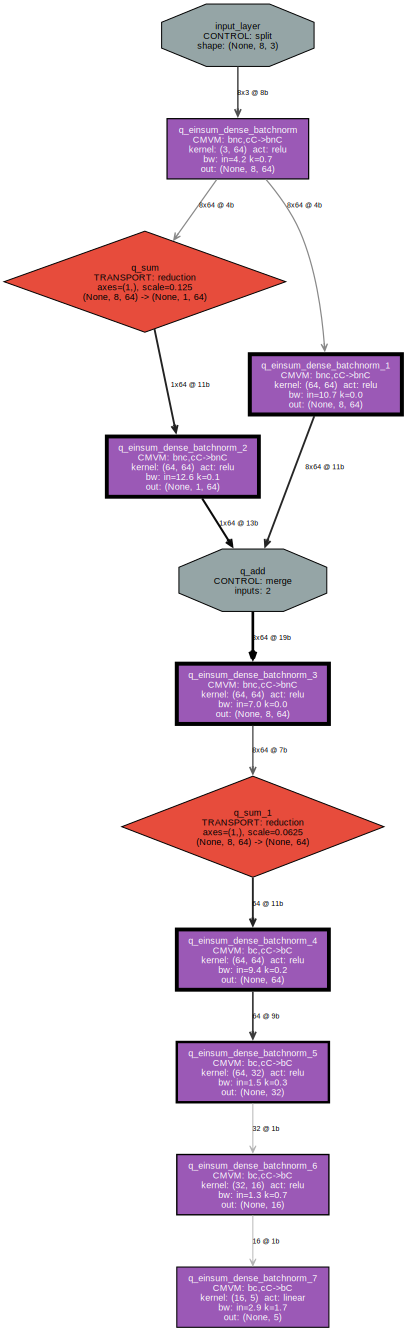

In [18]:
# Render the IR graph to SVG
output_path = g.render(filename='jedi_linear_ir', format='svg')
print(f"Graph rendered to: {output_path}")

# Display inline in notebook
display(SVG(filename=output_path))

## Step 18: Alternative View — Compute-Cost Weighted

Let's render a second view where node **size is proportional to kernel parameter count**. This previews the hardware cost distribution that da4ml will quantify in Phase 4.

In this view, the largest nodes are the ones that will consume the most FPGA LUTs — immediately showing where optimization effort should focus.

Cost-weighted graph rendered to: jedi_linear_ir_cost_weighted.svg


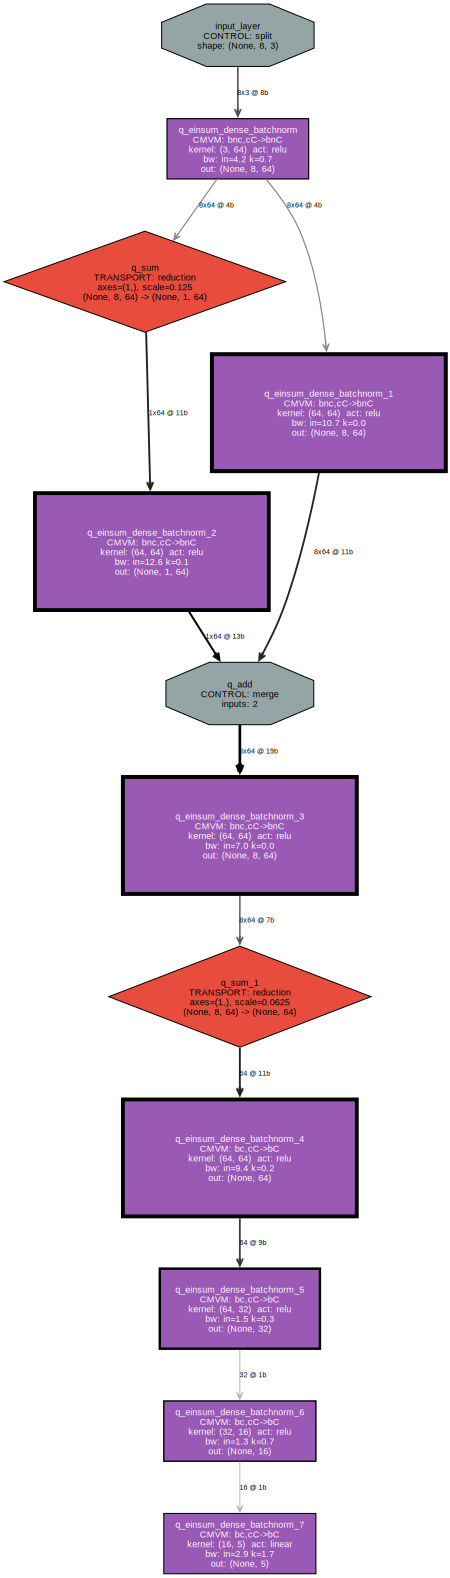


Kernel Parameter Ranking (largest → smallest):
  1. vx=3 q_einsum_dense_batchnorm_1          kernel=(64, 64)     params= 4,096
  2. vx=4 q_einsum_dense_batchnorm_2          kernel=(64, 64)     params= 4,096
  3. vx=6 q_einsum_dense_batchnorm_3          kernel=(64, 64)     params= 4,096
  4. vx=8 q_einsum_dense_batchnorm_4          kernel=(64, 64)     params= 4,096
  5. vx=9 q_einsum_dense_batchnorm_5          kernel=(64, 32)     params= 2,048
  6. vx=10 q_einsum_dense_batchnorm_6          kernel=(32, 16)     params=   512
  7. vx=1 q_einsum_dense_batchnorm            kernel=(3, 64)      params=   192
  8. vx=11 q_einsum_dense_batchnorm_7          kernel=(16, 5)      params=    80


In [19]:
# ============================================================================
# COST-WEIGHTED VIEW: Node size proportional to kernel parameters
# ============================================================================

# Override width/height for this render based on kernel size
def cost_width(g, vx):
    p = g.pmap[vx]
    if p['ntype'] == 'cmvm' and p['kernel_shape']:
        kernel_size = 1
        for d in p['kernel_shape']:
            kernel_size *= d
        # Scale: 192 params → 1.5 inches, 4096 params → 3.5 inches
        return str(1.2 + kernel_size / 2000.0)
    return '1.2'

def cost_height(g, vx):
    p = g.pmap[vx]
    if p['ntype'] == 'cmvm' and p['kernel_shape']:
        kernel_size = 1
        for d in p['kernel_shape']:
            kernel_size *= d
        return str(0.6 + kernel_size / 4000.0)
    return '0.5'

# Apply cost-weighted sizing
g.vstyle['width'] = cost_width
g.vstyle['height'] = cost_height

# Render
output_path_cost = g.render(filename='jedi_linear_ir_cost_weighted', format='svg')
print(f"Cost-weighted graph rendered to: {output_path_cost}")
display(SVG(filename=output_path_cost))

# Print the kernel parameter ranking
print("\nKernel Parameter Ranking (largest → smallest):")
cmvm_nodes = [(vx, g.pmap[vx]) for vx in g.vertices if g.pmap[vx]['ntype'] == 'cmvm']
cmvm_ranked = sorted(cmvm_nodes, key=lambda x: np.prod(x[1]['kernel_shape']) if x[1]['kernel_shape'] else 0, reverse=True)

for rank, (vx, p) in enumerate(cmvm_ranked, 1):
    ks = p['kernel_shape']
    size = int(np.prod(ks)) if ks else 0
    print(f"  {rank}. vx={vx} {p['layer_name']:<35s} kernel={str(ks):<12s} params={size:>6,}")

## Step 19: Graph Queries — Demonstrating IR Traversal

One of Heterograph's key advantages is native graph traversal. Let's demonstrate the queries that Phase 5 analysis passes will use:

1. **Source/Sink detection** — Find entry and exit points
2. **Neighbor queries** — Walk the dataflow graph
3. **Path enumeration** — Find all paths through the interaction block
4. **Type-filtered queries** — Get all CMVM nodes, all transport nodes, etc.

These replace the hand-coded graph walking that would be needed with raw tensors or adjacency lists.

In [20]:
# ============================================================================
# GRAPH QUERIES — IR TRAVERSAL DEMONSTRATIONS
# ============================================================================

print("1. SOURCE / SINK DETECTION")
print("=" * 60)
for vx in g.source:
    print(f"   Source: vx={vx} — {g.pmap[vx]['layer_name']} ({g.pmap[vx]['ntype']})")
for vx in g.sink:
    print(f"   Sink:   vx={vx} — {g.pmap[vx]['layer_name']} ({g.pmap[vx]['ntype']})")

print("\n2. NEIGHBOR QUERIES")
print("=" * 60)
# Show the fork at Layer 1 (node transform → two paths)
fork_vx = [vx for vx in g.vertices if g.num_out_vx(vx) > 1]
for vx in fork_vx:
    targets = g.out_vx(vx)
    print(f"   Fork at vx={vx} ({g.pmap[vx]['layer_name']}):")
    for t in targets:
        print(f"     → vx={t} ({g.pmap[t]['layer_name']}) [{g.pmap[t]['ntype']}]")

# Show the merge at QAdd
merge_vx = [vx for vx in g.vertices if g.num_in_vx(vx) > 1]
for vx in merge_vx:
    sources = g.in_vx(vx)
    print(f"   Merge at vx={vx} ({g.pmap[vx]['layer_name']}):")
    for s in sources:
        print(f"     ← vx={s} ({g.pmap[s]['layer_name']}) [{g.pmap[s]['ntype']}]")

print("\n3. TYPE-FILTERED VERTEX LISTS")
print("=" * 60)
for ntype in ['cmvm', 'transport', 'control']:
    nodes = [vx for vx in g.vertices if g.pmap[vx]['ntype'] == ntype]
    marker = {'cmvm': '■', 'transport': '▲', 'control': '●'}[ntype]
    print(f"   {marker} {ntype} nodes: {nodes}")
    for vx in nodes:
        print(f"     vx={vx}: {g.pmap[vx]['layer_name']} — {g.pmap[vx]['op_kind']}")

print("\n4. PATH ENUMERATION: Interaction Block")
print("=" * 60)
# Trace the two parallel paths from the fork to the merge
fork = fork_vx[0] if fork_vx else None
merge = merge_vx[0] if merge_vx else None
if fork is not None and merge is not None:
    print(f"   Fork: vx={fork} ({g.pmap[fork]['layer_name']})")
    print(f"   Merge: vx={merge} ({g.pmap[merge]['layer_name']})")
    
    # BFS to find all paths from fork to merge
    def find_paths(g, start, end, path=None):
        if path is None:
            path = [start]
        if start == end:
            return [path]
        paths = []
        for next_vx in g.out_vx(start):
            if next_vx not in path:
                new_paths = find_paths(g, next_vx, end, path + [next_vx])
                paths.extend(new_paths)
        return paths
    
    all_paths = find_paths(g, fork, merge)
    for i, path in enumerate(all_paths):
        path_str = " → ".join(f"vx{v}({g.pmap[v]['layer_name']})" for v in path)
        path_types = " → ".join(g.pmap[v]['ntype'] for v in path)
        print(f"   Path {i+1}: {path_str}")
        print(f"           Types: {path_types}")

print("\n5. EDGE PROPERTY SUMMARY")
print("=" * 60)
total_volume = 0
for e in g.edges:
    vol = g.pmap[e].get('volume_bits') or 0
    total_volume += vol
    src_name = g.pmap[e[0]]['layer_name']
    dst_name = g.pmap[e[1]]['layer_name']
    bw = g.pmap[e].get('bitwidth', '?')
    shape = g.pmap[e].get('tensor_shape', '?')
    print(f"   {src_name} → {dst_name}: shape={shape}, bw={bw}, vol={vol} bits")
print(f"\n   Total data volume per inference: {total_volume:,} bits ({total_volume/8:,.0f} bytes)")

1. SOURCE / SINK DETECTION
   Source: vx=0 — input_layer (control)
   Sink:   vx=11 — q_einsum_dense_batchnorm_7 (cmvm)

2. NEIGHBOR QUERIES
   Fork at vx=1 (q_einsum_dense_batchnorm):
     → vx=2 (q_sum) [transport]
     → vx=3 (q_einsum_dense_batchnorm_1) [cmvm]
   Merge at vx=5 (q_add):
     ← vx=3 (q_einsum_dense_batchnorm_1) [cmvm]
     ← vx=4 (q_einsum_dense_batchnorm_2) [cmvm]

3. TYPE-FILTERED VERTEX LISTS
   ■ cmvm nodes: [1, 3, 4, 6, 8, 9, 10, 11]
     vx=1: q_einsum_dense_batchnorm — einsum_dense_bn
     vx=3: q_einsum_dense_batchnorm_1 — einsum_dense_bn
     vx=4: q_einsum_dense_batchnorm_2 — einsum_dense_bn
     vx=6: q_einsum_dense_batchnorm_3 — einsum_dense_bn
     vx=8: q_einsum_dense_batchnorm_4 — einsum_dense_bn
     vx=9: q_einsum_dense_batchnorm_5 — einsum_dense_bn
     vx=10: q_einsum_dense_batchnorm_6 — einsum_dense_bn
     vx=11: q_einsum_dense_batchnorm_7 — einsum_dense_bn
   ▲ transport nodes: [2, 7]
     vx=2: q_sum — reduction
     vx=7: q_sum_1 — reduction
 

## Phase 1.5 Summary

We have successfully:

1. **Defined the IR schema** (`vinit`, `einit`, `ginit`) with 20 vertex properties, 3 edge properties, and 5 graph-level properties
2. **Built the Heterograph IR** from the Phase 1 model inspection — 12 vertices (8 CMVM + 2 transport + 2 control), 12 edges
3. **Rendered two visualizations**:
   - **Standard view**: color-coded by node type, labeled with full metadata
   - **Cost-weighted view**: node size proportional to kernel parameters — previews FPGA resource distribution
4. **Demonstrated graph queries**: source/sink detection, fork/merge identification, path enumeration, type-filtered traversal

### What this enables for Phase 2+

The IR graph is now the **single source of truth**. All subsequent phases read from `g.pmap`:
- **Phase 2** (IR schema formalization): The schema is already defined and populated
- **Phase 3** (Keras→IR converter): We've manually done the conversion — now automate it
- **Phase 4** (da4ml cost annotation): Fill `da4ml_lut_count` and `da4ml_latency` fields in each CMVM node's pmap
- **Phase 5** (Analysis passes): Use `g.vertices`, `g.in_vx()`, `g.out_vx()`, type-filtered queries to implement dominance classification, hotspot analysis, and pattern detection

### Key architectural insight from the visualization

The JEDI-linear model has a clear **compute-dominated profile**:
- 8 out of 12 nodes are CMVM (compute) — 67% of all nodes
- The interaction block's fork-merge pattern creates only 2 transport nodes (reductions)
- The 4 largest kernels (64×64 = 4,096 params each) are in layers 3, 4, 6, 8 — these will likely dominate FPGA LUT usage
- The classification MLP progressively reduces dimensions (64→32→16→5), so later layers are cheaper